# Circuits for Lesson 12 of the Tutorial

The 6 entries the Symbulator app lists under *Built-in Examples › Circuits for Lesson 12 of the Tutorial*, each run with the `symbulator` package. The circuits are read from the app's own file, not retyped. The same entries open in the app at https://symbulator.pythonanywhere.com/

If you are on Colab, run the first cell.

In [1]:
# On Google Colab the package is not installed yet; install it there.
# A local Jupyter already has it: pip install symbulator[notebook]
import sys
if "google.colab" in sys.modules:
    %pip install -q symbulator matplotlib

In [2]:
import sympy as sp
import matplotlib.pyplot as plt
from symbulator import (dc, ac, fd, tr, th, er, port, draw, polar,
                        evaluate, solve, bode_samples, time_samples, t, s)
import symbulator
symbulator.__version__

'0.6.17'

## 1. AS7's Example 16.1 (in TR, the one-step way)

Find vo(t), assuming zero initial conditions. This problem does not need the s-domain at all: the source is a function of time and so is the wanted answer, so TR does it in one step, with the source written in time.

![The circuit of AS7's Example 16.1 (in TR, the one-step way)](https://learn.symbulator.com/assets/circuit/as7e1601.png)

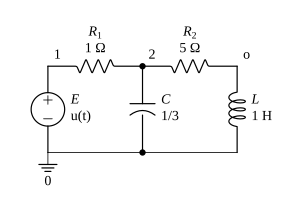

In [3]:
c1 = '''
e,1,0,u(t)
r1,1,2,1
r2,2,o,5
c,2,0,1/3,0
l,o,0,1,0
'''
draw(c1)

In [4]:
r1 = tr(c1)
r1

Result(domain='tr')
  i_c = (sqrt(2)*sin(sqrt(2)*t)/2 + cos(sqrt(2)*t))*exp(-4*t)
  i_e = -(exp(4*t) + sqrt(2)*sin(sqrt(2)*t) + 5*cos(sqrt(2)*t))*exp(-4*t)/6
  i_l = (exp(4*t) - 2*sqrt(2)*sin(sqrt(2)*t) - cos(sqrt(2)*t))*exp(-4*t)/6
  i_r1 = (exp(4*t) + sqrt(2)*sin(sqrt(2)*t) + 5*cos(sqrt(2)*t))*exp(-4*t)/6
  i_r2 = (exp(4*t) - 2*sqrt(2)*sin(sqrt(2)*t) - cos(sqrt(2)*t))*exp(-4*t)/6
  v_1 = 1
  v_2 = (5*exp(4*t) - sqrt(2)*sin(sqrt(2)*t) - 5*cos(sqrt(2)*t))*exp(-4*t)/6
  v_o = 3*sqrt(2)*exp(-4*t)*sin(sqrt(2)*t)/2

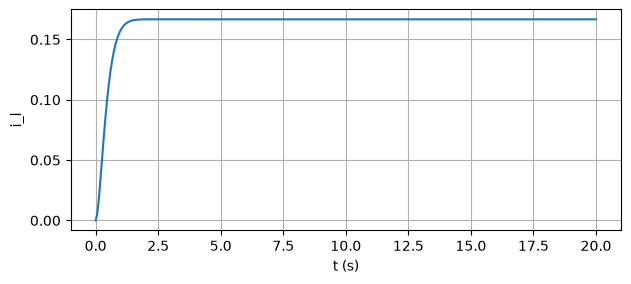

In [5]:
ts, ys = time_samples(c1, 'i_l', 20, t_min=0, n=300)
plt.figure(figsize=(6.5, 3))
plt.plot(ts, ys); plt.xlabel('t (s)'); plt.ylabel('i_l'); plt.grid(True); plt.tight_layout()

## 2. AS7's Example 16.1 (in FD, everything as an impedance)

In this problem, we run an FD (complex frequency domain) analysis for the first time: the same circuit, with the unit step written as 1/s. The capacitor written as 3/s and the inductor as s, to show it can be done. Only valid because the initial conditions are zero.

![The circuit of AS7's Example 16.1 (in FD, everything as an impedance)](https://learn.symbulator.com/assets/circuit/as7e1601.png)

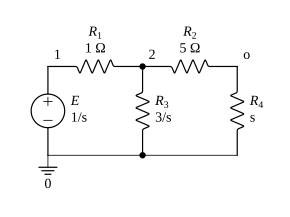

In [6]:
c2 = '''
e,1,0,1/s
r1,1,2,1
r2,2,o,5
r3,2,0,3/s
r4,o,0,s
'''
draw(c2)

In [7]:
r2 = fd(c2)
r2

Result(domain='fd')
  i_e = (-s**2 - 5*s - 3)/(s*(s**2 + 8*s + 18))
  i_r1 = (s**2 + 5*s + 3)/(s*(s**2 + 8*s + 18))
  i_r2 = 3/(s*(s**2 + 8*s + 18))
  i_r3 = (s + 5)/(s**2 + 8*s + 18)
  i_r4 = 3/(s*(s**2 + 8*s + 18))
  v_1 = 1/s
  v_2 = 3*(s + 5)/(s*(s**2 + 8*s + 18))
  v_o = 3/(s**2 + 8*s + 18)

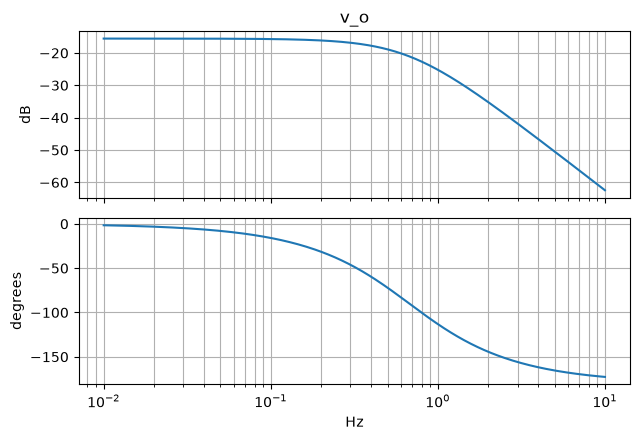

In [8]:
f, mag, phase = bode_samples(c2, 'v_o', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('v_o'); plt.tight_layout()

## 3. AS7's Example 16.1 (in FD, farads and henries)

Find vo(s) = 3/(s^2+8s+18). The same answer with the schematic's own units, which is what you would actually type. The source is 1/s, not 1 — in FD a bare 1 would be an impulse.

![The circuit of AS7's Example 16.1 (in FD, farads and henries)](https://learn.symbulator.com/assets/circuit/as7e1601.png)

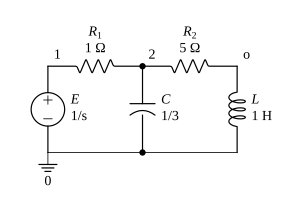

In [9]:
c3 = '''
e,1,0,1/s
r1,1,2,1
r2,2,o,5
c,2,0,1/3,0
l,o,0,1,0
'''
draw(c3)

In [10]:
r3 = fd(c3)
r3

Result(domain='fd')
  i_c = (s + 5)/(s**2 + 8*s + 18)
  i_e = (-s**2 - 5*s - 3)/(s*(s**2 + 8*s + 18))
  i_l = 3/(s*(s**2 + 8*s + 18))
  i_r1 = (s**2 + 5*s + 3)/(s*(s**2 + 8*s + 18))
  i_r2 = 3/(s*(s**2 + 8*s + 18))
  v_1 = 1/s
  v_2 = 3*(s + 5)/(s*(s**2 + 8*s + 18))
  v_o = 3/(s**2 + 8*s + 18)

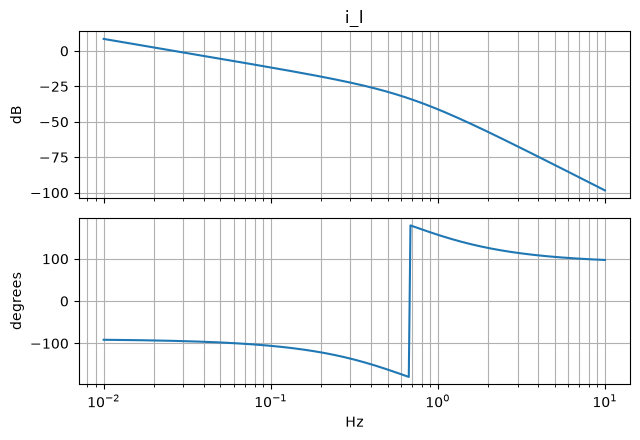

In [11]:
f, mag, phase = bode_samples(c3, 'i_l', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

## 4. AS7's Example 16.1 (in FD, and back to time)

The whole round trip: find vo(t) from an FD solve. t2s on the way in, s2t on the way out. Both work anywhere an expression is accepted.

![The circuit of AS7's Example 16.1 (in FD, and back to time)](https://learn.symbulator.com/assets/circuit/as7e1601.png)

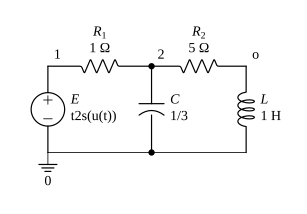

In [12]:
c4 = '''
e,1,0,t2s(u(t))
r1,1,2,1
r2,2,o,5
c,2,0,1/3,0
l,o,0,1,0
'''
draw(c4)

In [13]:
r4 = fd(c4)
r4

Result(domain='fd')
  i_c = (s + 5)/(s**2 + 8*s + 18)
  i_e = (-s**2 - 5*s - 3)/(s*(s**2 + 8*s + 18))
  i_l = 3/(s*(s**2 + 8*s + 18))
  i_r1 = (s**2 + 5*s + 3)/(s*(s**2 + 8*s + 18))
  i_r2 = 3/(s*(s**2 + 8*s + 18))
  v_1 = 1/s
  v_2 = 3*(s + 5)/(s*(s**2 + 8*s + 18))
  v_o = 3/(s**2 + 8*s + 18)

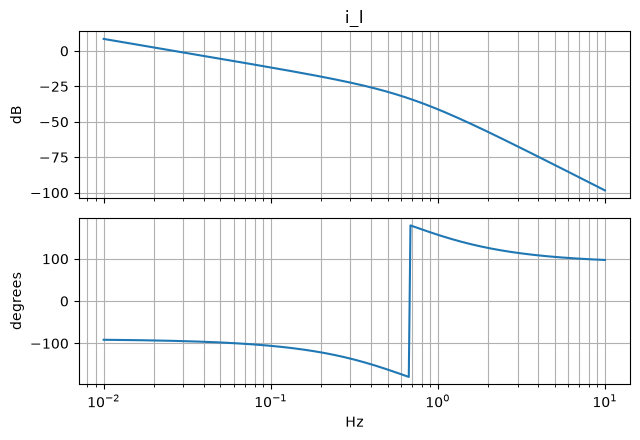

In [14]:
f, mag, phase = bode_samples(c4, 'i_l', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

In [15]:
evaluate(r4, 's2t(vo)')

3*sqrt(2)*exp(-4*t)*sin(sqrt(2)*t)/2

## 5. AS7's Practice Problem 16.1

Determine vo(t): the same shape as the example — solve in FD with the source converted by t2s, then transform the answer back with s2t(vo) on the Evaluate line.

![The circuit of AS7's Practice Problem 16.1](https://learn.symbulator.com/assets/circuit/as7pp1601.png)

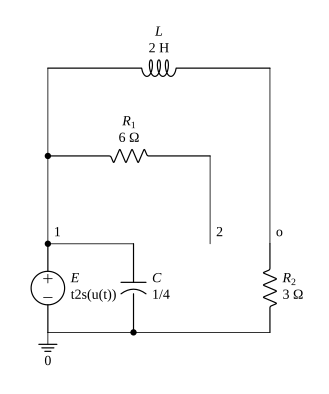

In [16]:
c5 = '''
e,1,0,t2s(u(t))
r1,1,2,6
c,1,0,1/4,0
l,1,o,2,0
r2,o,0,3
'''
draw(c5)

In [17]:
r5 = fd(c5)
r5

Result(domain='fd')
  i_c = 1/4
  i_e = (-2*s**2 - 3*s - 4)/(4*s*(2*s + 3))
  i_l = 1/(s*(2*s + 3))
  i_r1 = 0
  i_r2 = 1/(s*(2*s + 3))
  v_1 = 1/s
  v_2 = 1/s
  v_o = 3/(s*(2*s + 3))

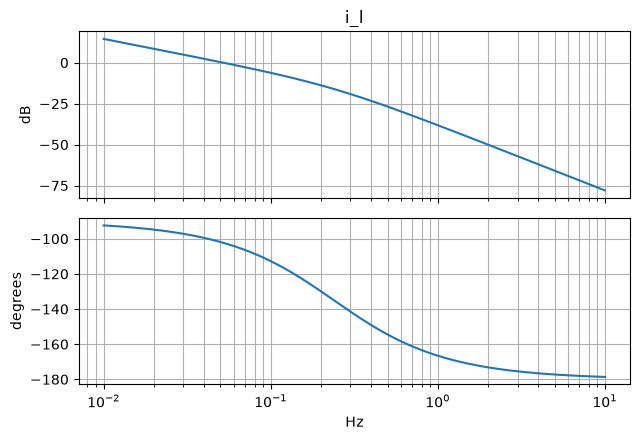

In [18]:
f, mag, phase = bode_samples(c5, 'i_l', 0.01, 10, n=300)
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(6.5, 4.5))
a1.semilogx(f, mag); a1.set_ylabel('dB'); a1.grid(True, which='both')
a2.semilogx(f, phase); a2.set_ylabel('degrees'); a2.set_xlabel('Hz'); a2.grid(True, which='both')
a1.set_title('i_l'); plt.tight_layout()

In [19]:
evaluate(r5, 's2t(vo)')

1 - exp(-3*t/2)

## 6. NR11's Example 13.7 (transfer function)

Find the transfer function H(s) = Vo/Vs — the Evaluate line, vo/vs. A transfer function needs no special tool: solve with a symbolic source and divide.

![The circuit of NR11's Example 13.7 (transfer function)](https://learn.symbulator.com/assets/circuit/nr11e1307.png)

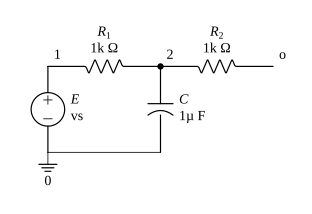

In [20]:
c6 = '''
e,1,0,vs
r1,1,2,1'k
c,2,0,1'µ
r2,2,o,1'k
'''
draw(c6)

In [21]:
r6 = fd(c6)
r6

Result(domain='fd')
  i_c = s*vs/(1000*(s + 1000))
  i_e = -s*vs/(1000*s + 1000000)
  i_r1 = s*vs/(1000*(s + 1000))
  i_r2 = 0
  v_1 = vs
  v_2 = 1000*vs/(s + 1000)
  v_o = 1000*vs/(s + 1000)

In [22]:
evaluate(r6, 'vo/vs')

1000/(s + 1000)